<a href="https://colab.research.google.com/github/MirMaiti/Hanyang_DesignProject/blob/main/MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANN for MNIST Dataset

In [ ]:
import cv2   # Library for computer vision tasks (though not directly used in this version)
import numpy as np   # Fundamental package for numerical computing, especially arrays
import tensorflow as tf   # Main library for building and training neural networks
import matplotlib.pyplot as plt   # Library for creating static, interactive, and animated visualizations
import os # Module for interacting with the operating system, used for file paths

In [ ]:
# Load the MNIST dataset directly from TensorFlow Keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Print the shapes of the loaded datasets to understand their dimensions
print('The shape of the training inputs:', X_train.shape)
print('The shape of the training labels:',y_train.shape)
print('The shape of the testing inputs:',X_test.shape)
print('The shape of the testing labels:',X_test.shape)

The shape of the training inputs: (60000, 28, 28)
The shape of the training labels: (60000,)
The shape of the testing inputs: (10000, 28, 28)
The shape of the testing labels: (10000, 28, 28)


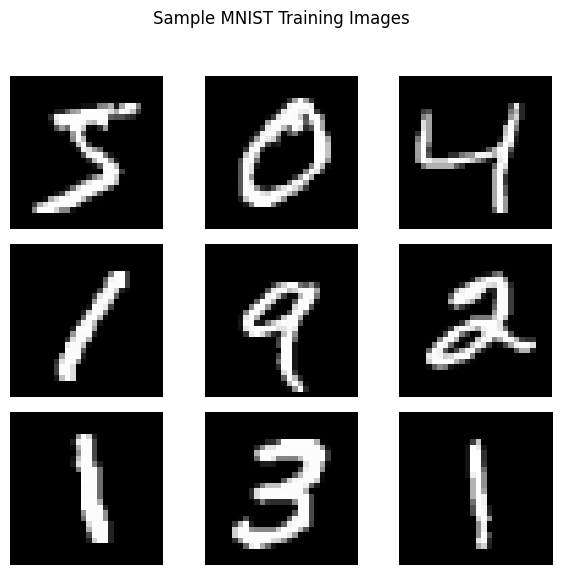

In [ ]:
# Plotting the first 9 images in the train set of MNIST

fig, axs = plt.subplots(3, 3, figsize=(6, 6))
cnt = 0
for i in range(3):
     for j in range(3):
         axs[i, j].imshow(X_train[cnt], cmap='gray') # Use 'gray' colormap for grayscale images
         axs[i, j].axis('off') # Hide axes ticks
         cnt += 1
plt.suptitle('Sample MNIST Training Images')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# Normalize the input images: pixel values are scaled from [0, 255] to [0, 1]
# The normalization is applied along axis=1 (across the pixels of each image)
X_train = tf.keras.utils.normalize(X_train, axis=1)
X_test = tf.keras.utils.normalize(X_test, axis=1)

In [ ]:
# Initialize a sequential model, which is a linear stack of layers
model = tf.keras.models.Sequential()


In [ ]:
# Input layer: Flattens the 28x28 2D image arrays into 1D vectors of 784 pixels
# Using `Input(shape)` is recommended for specifying input shape in Sequential models
model.add(tf.keras.Input(shape=(28, 28))) # Define input shape directly
model.add(tf.keras.layers.Flatten()) # Flatten the 28x28 images into 784-element vectors

In [ ]:
# First hidden layer: 128 neurons with Rectified Linear Unit (ReLU) activation function
model.add(tf.keras.layers.Dense(units=128, activation=tf.nn.relu, name='hidden_layer_1'))
# Second hidden layer: Another 128 neurons with ReLU activation
model.add(tf.keras.layers.Dense(units=128, activation=tf.nn.relu, name='hidden_layer_2'))

In [ ]:
# Output layer: 10 neurons (one for each digit 0-9) with softmax activation function
# Softmax ensures the output is a probability distribution over the 10 classes
model.add(tf.keras.layers.Dense(units=10, activation=tf.nn.softmax, name='output_layer'))

In [ ]:
# Display a summary of the model's architecture, including layer names, output shapes, and number of parameters
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model: Configure the learning process
# optimizer='adam': An efficient stochastic gradient descent optimizer
# loss='sparse_categorical_crossentropy': Suitable for integer labels (non-one-hot encoded)
# metrics=['accuracy']: Monitor the accuracy during training and evaluation
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model using the training data
# epochs=10: The number of complete passes through the training dataset
# batch_size=100: The number of samples per gradient update
print("Training Standard ANN Model...")
model.fit(X_train, y_train, epochs=10, batch_size=100)

Training Standard ANN Model...
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8383 - loss: 0.6314
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9584 - loss: 0.1403
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9707 - loss: 0.0951
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0674
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0510
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9869 - loss: 0.0422
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0316
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9911 - loss: 0.0261
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9944 - loss: 0.0189
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9940 - loss: 0.0179


In [ ]:
# Evaluate the model's performance on the test dataset
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss (Standard ANN): {loss:.4f}")
print(f"Test Accuracy (Standard ANN): {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9669 - loss: 0.1332

Test Loss (Standard ANN): 0.1149
Test Accuracy (Standard ANN): 0.9721


In [ ]:
# Make predictions on the test dataset
# The output will be an array of probability distributions for each test image
print("Making predictions on the test set...")
prediction = model.predict(X_test)

Making predictions on the test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Probabilities for image 67:  [1.4277562e-13 3.0251424e-10 2.6968705e-06 4.1749554e-10 9.9999726e-01
 7.3878322e-13 5.0059889e-15 1.7065704e-08 3.7174826e-11 9.6192618e-09]
Predicted digit for image 67:  4


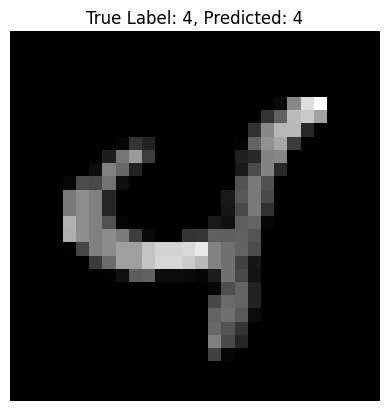

In [ ]:
# Let's examine a single prediction (e.g., for the 67th image in the test set)
print('Probabilities for image 67: ', prediction[67])
print('Predicted digit for image 67: ', np.argmax(prediction[67]))

# Optionally, display the image itself to verify the prediction
plt.imshow(X_test[67], cmap='gray')
plt.title(f"True Label: {y_test[67]}, Predicted: {np.argmax(prediction[67])}")
plt.axis('off')
plt.show()

In [ ]:
# Save the trained standard ANN model for future use
model.save('mnist_trained_model.keras')
print("Standard ANN model saved to 'mnist_trained_model.keras'")

Standard ANN model saved to 'mnist_trained_model.keras'


Extracting the weights

In [ ]:
import tensorflow as tf
import numpy as np

# -------------------------------------------------
# Step 1: Define + REGISTER the custom layer (tf.keras)
# This is necessary for loading the model correctly.
# -------------------------------------------------
@tf.keras.utils.register_keras_serializable(package="Custom")
class PositiveDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w_raw = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="w_raw"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )
        super().build(input_shape)

    def call(self, inputs):
        w_pos = tf.nn.softplus(self.w_raw) # Ensures weights are strictly > 0
        return tf.matmul(inputs, w_pos) + self.b

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

# -------------------------------------------------
# Step 2: Load the trained Positive-Weight model
# We use the MODEL_PATH_POSITIVE defined previously.
# -------------------------------------------------
MODEL_PATH_POSITIVE = "/content/mnist_784_10_positive.keras"

try:
    model_loaded_positive = tf.keras.models.load_model(
        MODEL_PATH_POSITIVE,
        custom_objects={"PositiveDense": PositiveDense}
    )
    print("✅ Positive-Weight Model loaded successfully from:", MODEL_PATH_POSITIVE)
except Exception as e:
    print(f"❌ Error loading positive-weight model: {e}")
    print("Please ensure the model was trained and saved correctly in the previous step.")
    exit()

# -------------------------------------------------
# Step 3: Extract effective positive weights & biases
# -------------------------------------------------
# The PositiveDense layer is the first (and only) custom layer in our sequential model
positive_layer_loaded = model_loaded_positive.get_layer('positive_dense_layer')

# Raw (unconstrained) parameters
W_raw_extracted = positive_layer_loaded.w_raw.numpy()   # (784, 10)
bias_extracted = positive_layer_loaded.b.numpy()          # (10,)

# Effective positive weights (after softplus transformation)
W_pos_extracted = tf.nn.softplus(W_raw_extracted).numpy()

# -------------------------------------------------
# Step 4: Print structure of extracted parameters
# -------------------------------------------------
print("\n--- Extracted parameters from loaded Positive-Weight Model ---")
print("W_raw_extracted shape :", W_raw_extracted.shape)
print("W_pos_extracted shape :", W_pos_extracted.shape)
print("Bias_extracted shape  :", bias_extracted.shape)
print("Min W_pos_extracted   :", W_pos_extracted.min()) # Should be > 0

# -------------------------------------------------
# Step 5: Save for reuse (optional) - these are already saved, but re-saving with clearer names
# -------------------------------------------------
np.save("/content/W_pos_extracted.npy", W_pos_extracted)
np.save("/content/bias_extracted.npy", bias_extracted)

print("\nSaved extracted weights and biases:")
print(" - /content/W_pos_extracted.npy")
print(" - /content/bias_extracted.npy")

✅ Positive-Weight Model loaded successfully from: /content/mnist_784_10_positive.keras

--- Extracted parameters from loaded Positive-Weight Model ---
W_raw_extracted shape : (784, 10)
W_pos_extracted shape : (784, 10)
Bias_extracted shape  : (10,)
Min W_pos_extracted   : 0.29833102

Saved extracted weights and biases:
 - /content/W_pos_extracted.npy
 - /content/bias_extracted.npy


In [ ]:
# This cell is no longer needed as extraction is handled by `N8zSsIh99rrH` and `FhGF9QRL3ZJi`.

In [ ]:
# Verify the first few values of the extracted positive weights
print("Sample of W_pos_extracted (first few values):\n", W_pos_extracted[:5, :5])

Sample of W_pos_extracted (first few values):
 [[0.69213295 0.70373267 0.7048253  0.6619593  0.652581  ]
 [0.6675817  0.68313277 0.71846825 0.7092286  0.7320962 ]
 [0.6640743  0.65068835 0.69005203 0.70716786 0.70402175]
 [0.7028645  0.732676   0.6809154  0.7293891  0.7367391 ]
 [0.6736324  0.6864171  0.69797283 0.70433766 0.6898689 ]]


Array Quantizer function

In [ ]:
import numpy as np

def asymmetric_int4_quantizer_updated(arr_float):
    """
    Quantizes a floating-point array to 4-bit integers (0-7) using asymmetric scaling.

    Args:
        arr_float (np.ndarray): The input floating-point array.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The quantized integer array (values clipped to [0, 7]).
            - float: The maximum absolute value of the original array, used as a scale factor.
    """
    # Calculate the scale factor based on the maximum absolute value of the array
    # The range [0, 7] has 8 possible values. We scale to use 4 as the zero point.
    scale = np.max(abs(arr_float)) / 4

    # Scale and shift the float values, then round to the nearest integer
    # The original formula `arr_float / scale + 4` maps values from [-max_abs, +max_abs]
    # to approximately [0, 8] if scale is max_abs/4.
    # If original values are all positive, then the range is [0, +max_abs]
    # which maps to [4, 8].
    X_signed = np.round(arr_float / scale + 4)

    # Clip values to the 4-bit unsigned integer range [0, 7]
    W_quantized = np.clip(X_signed, 0, 7)

    print("\n--- Quantization Details ---")
    print("Scale factor used:", scale)
    print("Sample of scaled+shifted values (before clipping):\n", X_signed.flatten()[:10])
    print("Sample of quantized values (clipped to [0, 7]):\n", W_quantized.flatten()[:10])

    return W_quantized, np.max(abs(arr_float))

# Load the extracted weights and biases from the positive-weight model
# Using the .npy files saved in the previous step for clarity
loaded_W_pos = np.load("/content/W_pos_extracted.npy")
loaded_bias = np.load("/content/bias_extracted.npy")

# Quantize the bias and weights
bias_int4, max_bias = asymmetric_int4_quantizer_updated(loaded_bias)
weight_int4, max_weight = asymmetric_int4_quantizer_updated(loaded_W_pos)

print("\nBias Quantization:")
print("Quantized Bias shape:", bias_int4.shape)
print("Original max abs bias:", max_bias)

print("\nWeight Quantization:")
print("Quantized Weight shape:", weight_int4.shape)
print("Original max abs weight:", max_weight)


--- Quantization Details ---
Scale factor used: 0.20604917
Sample of scaled+shifted values (before clipping):
 [2. 7. 4. 3. 5. 7. 4. 6. 0. 3.]
Sample of quantized values (clipped to [0, 7]):
 [2. 7. 4. 3. 5. 7. 4. 6. 0. 3.]

--- Quantization Details ---
Scale factor used: 0.3634762
Sample of scaled+shifted values (before clipping):
 [6. 6. 6. 6. 6. 6. 6. 6. 6. 6.]
Sample of quantized values (clipped to [0, 7]):
 [6. 6. 6. 6. 6. 6. 6. 6. 6. 6.]

Bias Quantization:
Quantized Bias shape: (10,)
Original max abs bias: 0.8241967

Weight Quantization:
Quantized Weight shape: (784, 10)
Original max abs weight: 1.4539047


In [ ]:
import numpy as np

def dequantizer_int4_asymmetric(arr_int4, original_max_abs):
    """
    De-quantizes a [0, 7] integer array back to approximate floating-point values
    using the original maximum absolute value as a scale factor.

    Args:
        arr_int4 (np.ndarray): The quantized integer array (values [0, 7]).
        original_max_abs (float): The maximum absolute value from the original
                                   floating-point array, used to reconstruct the scale.

    Returns:
        np.ndarray: The reconstructed float32 array.
    """
    if original_max_abs == 0.0:
        return np.zeros_like(arr_int4, dtype=np.float32)

    # Reconstruct the scale factor used during quantization
    scale = original_max_abs / 4

    # Reverse the quantization steps: subtract 4, then multiply by scale
    arr_float_reconstructed = (arr_int4.astype(np.float32) - 4) * scale

    return arr_float_reconstructed

# --- De-quantize the weights and biases ---
print("\n--- Dequantization Process ---")
dequantized_bias = dequantizer_int4_asymmetric(bias_int4, max_bias)
dequantized_weight = dequantizer_int4_asymmetric(weight_int4, max_weight)

print(f"\nDequantized Bias (first 10 values): {dequantized_bias[:10]}")
print(f"Dequantized Weight (first 5x5 values):\n {dequantized_weight[:5, :5]}")

# Note: Dequantized data will be close to the original but will show some error
# due to rounding during quantization (quantization noise). We can check the difference.
print(f"\nMax absolute difference for Bias: {np.max(np.abs(loaded_bias - dequantized_bias)):.6f}")
print(f"Max absolute difference for Weights: {np.max(np.abs(loaded_W_pos - dequantized_weight)):.6f}")


--- Dequantization Process ---

Dequantized Bias (first 10 values): [-0.41209835  0.6181475   0.         -0.20604917  0.20604917  0.6181475
  0.          0.41209835 -0.8241967  -0.20604917]
Dequantized Weight (first 5x5 values):
 [[0.7269524 0.7269524 0.7269524 0.7269524 0.7269524]
 [0.7269524 0.7269524 0.7269524 0.7269524 0.7269524]
 [0.7269524 0.7269524 0.7269524 0.7269524 0.7269524]
 [0.7269524 0.7269524 0.7269524 0.7269524 0.7269524]
 [0.7269524 0.7269524 0.7269524 0.7269524 0.7269524]]

Max absolute difference for Bias: 0.095091
Max absolute difference for Weights: 0.363476


Creating model using dequantizer output

In [ ]:
# ==========================================
# Keras Inference Model using Dequantized Weights
# 784 -> 10 (MNIST)
# ==========================================

import numpy as np
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------
# Step 1: Use the dequantized weights & bias
# These variables ('dequantized_weight', 'dequantized_bias') are from the previous step
# ------------------------------------------------
deq_W = dequantized_weight    # shape: (784, 10)
deq_bias  = dequantized_bias  # shape: (10,)

# Sanity checks
assert deq_W.shape == (784, 10)
assert deq_bias.shape == (10,)
# Note: dequantized weights might not be strictly positive due to quantization error,
# but they should be close to the original positive weights.

print("\nLoaded dequantized weights:")
print("Dequantized Weight shape:", deq_W.shape)
print("Dequantized Bias shape  :", deq_bias.shape)
print("Min dequantized weight :", deq_W.min())

# ------------------------------------------------
# Step 2: Build a NEW Keras model (matching the architecture of the PositiveDense model)
# ------------------------------------------------
model_dequantized = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)), # Expects flattened 28x28 images
    tf.keras.layers.Dense(
        10, # Output 10 classes
        activation="softmax", # Softmax for probability distribution
        use_bias=True, # Include bias
        name='dequantized_dense_layer'
    )
])

# ------------------------------------------------
# Step 3: Inject dequantized weights into the model
# Keras `set_weights` expects a list: [weights_matrix, bias_vector]
# ------------------------------------------------
model_dequantized.get_layer('dequantized_dense_layer').set_weights([deq_W, deq_bias])

# Compile (needed for evaluation)
model_dequantized.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n✅ New Keras model created and dequantized weights injected")
model_dequantized.summary()

# ------------------------------------------------
# Step 4: Load MNIST test data (if not already loaded or reshaped for this model)
# We'll use the preprocessed x_test_positive, y_test_positive from the positive-weight model section
# ------------------------------------------------
(_, _), (x_test_for_eval, y_test_for_eval) = tf.keras.datasets.mnist.load_data()
x_test_for_eval = x_test_for_eval.astype("float32") / 255.0
x_test_for_eval = x_test_for_eval.reshape(-1, 784)

# ------------------------------------------------
# Step 5: Evaluate performance with dequantized weights
# ------------------------------------------------
print("\nEvaluating model with dequantized weights...")
test_loss_dequantized, test_acc_dequantized = model_dequantized.evaluate(
    x_test_for_eval,
    y_test_for_eval,
    batch_size=512,
    verbose=1
)

print(f"\n🎯 Test Accuracy (Dequantized Model): {test_acc_dequantized * 100:.2f}%")

# ------------------------------------------------
# Step 6: Predict a few samples (sanity check)
# ------------------------------------------------
print("\nMaking sample predictions with dequantized model...")
preds_dequantized = model_dequantized.predict(x_test_for_eval[:10])
pred_digits_dequantized = np.argmax(preds_dequantized, axis=1)

print("Sample predictions (Dequantized Model):")
print("Predicted:  ", pred_digits_dequantized)
print("GroundTruth:", y_test_for_eval[:10])

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Loaded dequantized weights:
Dequantized Weight shape: (784, 10)
Dequantized Bias shape  : (10,)
Min dequantized weight : 0.3634762

✅ New Keras model created and dequantized weights injected


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dequantized_dense_layer (Dense) │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)


Evaluating model with dequantized weights...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7183 - loss: 0.8800

🎯 Test Accuracy (Dequantized Model): 73.90%

Making sample predictions with dequantized model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Sample predictions (Dequantized Model):
Predicted:   [7 6 1 0 4 1 4 9 6 9]
GroundTruth: [7 2 1 0 4 1 4 9 5 9]


In [ ]:
# This cell is no longer needed as the model with dequantized weights is built directly.

In [ ]:
# This cell is no longer needed as the model with dequantized weights is built directly.

In [ ]:
# This cell is no longer needed.

# Constraining the weights to be positive

In [ ]:
import os
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# --- Config ---
MODEL_PATH_POSITIVE = "/content/mnist_784_10_positive.keras" # Path to save/load the positive-weight model
EPOCHS_POSITIVE = 10
BATCH_SIZE_POSITIVE = 256
LR_POSITIVE = 1e-3

# --- Load MNIST (auto-download) ---
# The data is already loaded, but we'll reshape it for this specific model's input
(x_train_positive, y_train_positive), (x_test_positive, y_test_positive) = tf.keras.datasets.mnist.load_data()

# Normalize and flatten for a 784-input model
x_train_positive = x_train_positive.astype("float32") / 255.0
x_test_positive  = x_test_positive.astype("float32") / 255.0

x_train_positive = x_train_positive.reshape(-1, 28 * 28) # Flatten 28x28 to 784
x_test_positive  = x_test_positive.reshape(-1, 28 * 28)

# --- Custom Positive Dense Layer ---
@tf.keras.utils.register_keras_serializable(package="Custom") # Register for serialization
class PositiveDense(tf.keras.layers.Layer):
    """
    Dense layer with strictly positive weights using softplus activation on raw weights.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # Raw (unconstrained) weights which will be transformed to positive
        self.w_raw = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="w_raw"
        )
        # Bias term
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )
        super().build(input_shape)

    def call(self, inputs):
        # Apply softplus to raw weights to ensure positivity
        w_pos = tf.nn.softplus(self.w_raw)   # Ensures weights are strictly > 0
        return tf.matmul(inputs, w_pos) + self.b

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units}) # Include custom parameters in config
        return config

# --- Build Model (784 -> 10) ---
model_positive = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)), # Input layer expects flattened 784-pixel images
    PositiveDense(10, name='positive_dense_layer'), # Custom dense layer with positive weights
    tf.keras.layers.Softmax() # Softmax activation for probability distribution over 10 classes
])

print("\nPositive-Weight ANN Model Architecture:")
model_positive.summary()

# --- Compile ---
model_positive.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_POSITIVE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Load or Train ---
if os.path.exists(MODEL_PATH_POSITIVE):
    print("\nLoading saved positive-weight model...")
    model_positive = tf.keras.models.load_model(
        MODEL_PATH_POSITIVE,
        custom_objects={"PositiveDense": PositiveDense}
    )
else:
    print("\nTraining positive-weight model...")
    model_positive.fit(
        x_train_positive, y_train_positive,
        epochs=EPOCHS_POSITIVE,
        batch_size=BATCH_SIZE_POSITIVE,
        validation_data=(x_test_positive, y_test_positive),
        verbose=1
    )

    # Save model
    model_positive.save(MODEL_PATH_POSITIVE)
    print("Positive-Weight ANN model saved to:", MODEL_PATH_POSITIVE)

# --- Evaluate ---
test_loss_positive, test_acc_positive = model_positive.evaluate(x_test_positive, y_test_positive, verbose=0)
print(f"\nTest Accuracy (Positive-Weight ANN): {test_acc_positive * 100:.2f}%")

# --- Sanity check: weights > 0 and extract them for quantization ---
positive_layer = model_positive.get_layer('positive_dense_layer') # Get the custom layer
w_raw_positive_model = positive_layer.w_raw.numpy()
W_pos_positive_model = tf.nn.softplus(w_raw_positive_model).numpy() # Ensure weights are positive
bias_positive_model = positive_layer.b.numpy()

print("\nExtracted weights from Positive-Weight Model:")
print("Weight matrix shape:", W_pos_positive_model.shape)
print("Minimum weight value (should be > 0):", W_pos_positive_model.min())
print("Bias vector shape:", bias_positive_model.shape)

# Save for later use in quantization
np.save("/content/W_pos_positive_model.npy", W_pos_positive_model)
np.save("/content/bias_positive_model.npy", bias_positive_model)
print("Saved W_pos_positive_model.npy and bias_positive_model.npy")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Positive-Weight ANN Model Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positive_dense_layer            │ (None, 10)             │         7,850 │
│ (PositiveDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)


Loading saved positive-weight model...

Test Accuracy (Positive-Weight ANN): 91.67%

Extracted weights from Positive-Weight Model:
Weight matrix shape: (784, 10)
Minimum weight value (should be > 0): 0.29833102
Bias vector shape: (10,)
Saved W_pos_positive_model.npy and bias_positive_model.npy


In [ ]:
# Display a sample of the extracted positive weights
print("Sample of W_pos_positive_model (first few values):\n", W_pos_positive_model[:5, :5])

Sample of W_pos_positive_model (first few values):
 [[0.69213295 0.70373267 0.7048253  0.6619593  0.652581  ]
 [0.6675817  0.68313277 0.71846825 0.7092286  0.7320962 ]
 [0.6640743  0.65068835 0.69005203 0.70716786 0.70402175]
 [0.7028645  0.732676   0.6809154  0.7293891  0.7367391 ]
 [0.6736324  0.6864171  0.69797283 0.70433766 0.6898689 ]]


In [ ]:
import numpy as np

# Get the first image from the original training dataset (before normalization for visualization)
# We'll use the X_train loaded at the beginning for this visualization
first_image_original = tf.keras.datasets.mnist.load_data()[0][0][0] # Get first image of training set

# Flatten the 28x28 image into a 1D array of 784 pixels
flattened_image = first_image_original.flatten()

# Scale the pixel values (0-255) to 0-255 (already in this range for original image) and convert to integers
scaled_image_int = flattened_image.astype(int)

# Convert each integer pixel value to a two-digit hexadecimal string
hex_values = [f'{pixel:02x}' for pixel in scaled_image_int]

# Define the filename for the image data
filename_image = 'mnist_first_image_hex.txt'

# Save the hexadecimal values to the text file, one per line
with open(filename_image, 'w') as f:
    for hex_val in hex_values:
        f.write(hex_val + '\n')

print(f'Successfully saved the first MNIST image (784 hex values) to {filename_image}')

Successfully saved the first MNIST image (784 hex values) to mnist_first_image_hex.txt


In [ ]:
import numpy as np

# Ensure 'weight_int4' array exists from previous quantization steps
# 'weight_int4' is the quantized weight matrix (784, 10)

if 'weight_int4' in locals() and isinstance(weight_int4, np.ndarray):
    # Check if the shape is (784, 10)
    if weight_int4.shape == (784, 10):
        # Iterate through each column of the 'weight_int4' array (each column represents weights for one output class)
        for i in range(weight_int4.shape[1]):
            # Extract the current column and convert to integer type
            column_data = weight_int4[:, i].astype(int)

            # Define the filename for the current column
            filename_column = f'quantized_weights_column_{i}.txt'

            # Save the column data to a text file, one element per line
            np.savetxt(filename_column, column_data, fmt='%s')
            print(f'Saved quantized column {i} to {filename_column}')
    else:
        print(f"Error: 'weight_int4' array has shape {weight_int4.shape}, expected (784, 10).")
else:
    print("Error: 'weight_int4' array not found. Please ensure it has been created and quantized.")

Saved quantized column 0 to quantized_weights_column_0.txt
Saved quantized column 1 to quantized_weights_column_1.txt
Saved quantized column 2 to quantized_weights_column_2.txt
Saved quantized column 3 to quantized_weights_column_3.txt
Saved quantized column 4 to quantized_weights_column_4.txt
Saved quantized column 5 to quantized_weights_column_5.txt
Saved quantized column 6 to quantized_weights_column_6.txt
Saved quantized column 7 to quantized_weights_column_7.txt
Saved quantized column 8 to quantized_weights_column_8.txt
Saved quantized column 9 to quantized_weights_column_9.txt
